In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-07-04 09:09:21.641860: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 09:09:21.683837: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-04 09:09:25.988877: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glszm/kernel5-radius5/300.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-07-04 09:09:40.186986: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-04 09:09:40.188507: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpmyti71ft as temporary training directory


Reading training dataset...


Training dataset read in 0:00:03.500907. Found 235478 examples.


Training model...


[INFO 26-07-04 09:10:08.8829 UTC kernel.cc:1233] Loading model from path /tmp/tmpmyti71ft/model/ with prefix 1db74a637d4b497f


[INFO 26-07-04 09:10:10.4743 UTC decision_forest.cc:734] Model loaded with 300 root(s), 1384802 node(s), and 16 input feature(s).
[INFO 26-07-04 09:10:10.4743 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-07-04 09:10:10.4743 UTC kernel.cc:1061] Use fast generic engine


Model trained in 0:00:26.851236


Compiling model...


Model compiled.


CPU times: user 4min 45s, sys: 1.96 s, total: 4min 47s
Wall time: 33.5 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

 1/34 [..............................] - ETA: 1:38 - loss: 0.0000e+00 - accuracy: 0.9330

 3/34 [=>............................] - ETA: 1s - loss: 0.0000e+00 - accuracy: 0.9250  

 5/34 [===>..........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9232

 7/34 [=====>........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9190

 9/34 [======>.......................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9196

...

29/34 [========================>.....] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9190

31/34 [==========================>...] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9193

33/34 [============================>.] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9192

34/34 [==============================] - 4s 35ms/step - loss: 0.0000e+00 - accuracy: 0.9190



loss: 0.0000
accuracy: 0.9190


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (16):
	GrayLevelNonUniformity
	GrayLevelNonUniformityNormalized
	GrayLevelVariance
	HighGrayLevelZoneEmphasis
	LargeAreaEmphasis
	LargeAreaHighGrayLevelEmphasis
	LargeAreaLowGrayLevelEmphasis
	LowGrayLevelZoneEmphasis
	SizeZoneNonUniformity
	SizeZoneNonUniformityNormalized
	SmallAreaEmphasis
	SmallAreaHighGrayLevelEmphasis
	SmallAreaLowGrayLevelEmphasis
	ZoneEntropy
	ZonePercentage
	ZoneVariance

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.        "HighGrayLevelZoneEmphasis"  0.250050 ################
    2.           "GrayLevelNonUniformity"  0.143185 #####
    3.    "SmallAreaLowGrayLevelEmphasis"  0.131543 ####
    4.         "LowGrayLevelZoneEmphasis"  0.124418 ####
    5.    "LargeAreaLowGrayLevelEmphasis"  0.122807 ###
    6.   "SmallAreaHighGrayLevelEmphasis"  0.119618 ###
    7.  "SizeZoneNonUniformityNormalized"  0.100475 #
    8.                "GrayLevelVariance"  0.099424 #


In [11]:
# Model features
model.make_inspector().features()

["GrayLevelNonUniformity" (1; #0),
 "GrayLevelNonUniformityNormalized" (1; #1),
 "GrayLevelVariance" (1; #2),
 "HighGrayLevelZoneEmphasis" (1; #3),
 "LargeAreaEmphasis" (1; #4),
 "LargeAreaHighGrayLevelEmphasis" (1; #5),
 "LargeAreaLowGrayLevelEmphasis" (1; #6),
 "LowGrayLevelZoneEmphasis" (1; #7),
 "SizeZoneNonUniformity" (1; #8),
 "SizeZoneNonUniformityNormalized" (1; #9),
 "SmallAreaEmphasis" (1; #10),
 "SmallAreaHighGrayLevelEmphasis" (1; #11),
 "SmallAreaLowGrayLevelEmphasis" (1; #12),
 "ZoneEntropy" (1; #13),
 "ZonePercentage" (1; #14),
 "ZoneVariance" (1; #15)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("HighGrayLevelZoneEmphasis" (1; #3),
   0.25004990469486227),
  ("GrayLevelNonUniformity" (1; #0), 0.14318504949309985),
  ("SmallAreaLowGrayLevelEmphasis" (1; #12), 0.13154329893987793),
  ("LowGrayLevelZoneEmphasis" (1; #7), 0.1244179243028755),
  ("LargeAreaLowGrayLevelEmphasis" (1; #6), 0.1228070956175052),
  ("SmallAreaHighGrayLevelEmphasis" (1; #11), 0.11961809041395194),
  ("SizeZoneNonUniformityNormalized" (1; #9), 0.10047510429397835),
  ("GrayLevelVariance" (1; #2), 0.09942354097477957),
  ("LargeAreaHighGrayLevelEmphasis" (1; #5), 0.0978307751893908),
  ("ZoneVariance" (1; #15), 0.09096928407716817),
  ("SizeZoneNonUniformity" (1; #8), 0.09004683857206373),
  ("GrayLevelNonUniformityNormalized" (1; #1), 0.08967555956148544),
  ("SmallAreaEmphasis" (1; #10), 0.0896102051481539),
  ("ZoneEntropy" (1; #13), 0.08643343858353951),
  ("ZonePercentage" (1; #14), 0.08405922434507625),
  ("LargeAreaEmphasis" (1; #4), 0.08222992532470505)],
 'SUM_SCORE': [("Hi

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=235478, accuracy=0.8567020971260998, loss=0.49017429761896986, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

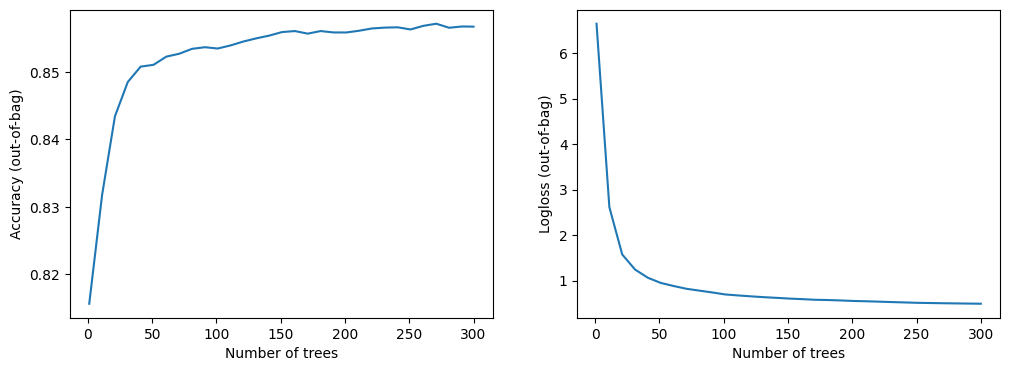

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/34 [..............................] - ETA: 3s

 3/34 [=>............................] - ETA: 1s

 5/34 [===>..........................] - ETA: 0s

 7/34 [=====>........................] - ETA: 0s

 9/34 [======>.......................] - ETA: 0s

...

29/34 [========================>.....] - ETA: 0s

31/34 [==========================>...] - ETA: 0s

33/34 [============================>.] - ETA: 0s

34/34 [==============================] - 1s 35ms/step


The ROC AUC score is 0.94431


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

 1/68 [..............................] - ETA: 6s

 3/68 [>.............................] - ETA: 2s

 5/68 [=>............................] - ETA: 2s

 7/68 [==>...........................] - ETA: 2s

 9/68 [==>...........................] - ETA: 2s

...

62/68 [==========================>...] - ETA: 0s

64/68 [===========================>..] - ETA: 0s

66/68 [============================>.] - ETA: 0s

68/68 [==============================] - 2s 36ms/step


Sklearn binary metrics:
accuracy: 0.9182
precision: 0.4149
recall: 0.7805
f1: 0.5418
mcc: 0.5318
roc_auc: 0.9439
pr_auc: 0.5943
log_loss: 0.2154
brier_score: 0.0607

Confusion matrix:
 [[58525  4587]
 [  915  3253]]

Classification report:
               precision    recall  f1-score   support

           0     0.9846    0.9273    0.9551     63112
           1     0.4149    0.7805    0.5418      4168

    accuracy                         0.9182     67280
   macro avg     0.6998    0.8539    0.7485     67280
weighted avg     0.9493    0.9182    0.9295     67280

